### Import Statements

In [3]:
import numpy as np
import pandas as pd
import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import scipy.stats

%matplotlib inline

In [4]:
from Bio import SeqIO
import plotly.express as px

# https://github.com/ipython/ipython/issues/10627
import os
os.environ['QT_QPA_PLATFORM']='offscreen'

In [5]:
import ete3 as ETE
from ete3 import Tree

In [6]:
import json

#### Pandas Viewing Settings

In [7]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

### Define paths to H37Rv genome masking schemes

In [8]:
RepoRef_Dir = "../../References"

MaskingSchemes_Dir = f"{RepoRef_Dir}/Mtb_H37Rv_MaskingSchemes"

PLC_Scheme_BED = f"{MaskingSchemes_Dir}/201027_Mtb_H37rv_pLC_Regions_CoscollaExcludedGenes.bed"
RLC_Scheme_BED = f"{MaskingSchemes_Dir}/RLC_Regions.H37Rv.bed"

EBR_Below09_Scheme_BED = f"{MaskingSchemes_Dir}/EBR_V7_36CI.Below_0.9.And.Ambiguous.Regions.bed"
LowPmap_K50E4_Scheme_BED = f"{MaskingSchemes_Dir}/RLC_Regions.Plus.MGEs.H37Rv.bed"

RLC_MGEs_Scheme_BED = f"{MaskingSchemes_Dir}/RLC_Regions.Plus.MGEs.H37Rv.bed"
RLC_LowPmap_K50E4_Scheme_BED = f"{MaskingSchemes_Dir}/RLC_Regions.Plus.LowPmapK50E4.H37Rv.bed"


AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions" 
H37Rv_GenomeAnnotations_Genes_And_IntergenicRegions_BED = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.And.IntergenicRegions.bed"


In [9]:
!ls -lah $MaskingSchemes_Dir

total 224K
drwxrwsr-x 2 mm774 farhat 166 Oct 18 11:21 .
drwxrwsr-x 9 mm774 farhat 467 Jan 24 16:17 ..
-rw-rw-r-- 1 mm774 farhat 26K Oct 18 11:21 201027_Mtb_H37rv_pLC_Regions_CoscollaExcludedGenes.bed
-rw-rw-r-- 1 mm774 farhat 30K Oct 18 11:21 201027_PMap_K50E4_Regions_BELOW_1.bed
-rw-rw-r-- 1 mm774 farhat 21K Oct 18 11:21 RLC_Regions.H37Rv.bed


In [10]:
!ls -lah $RLC_Scheme_BED

-rw-rw-r-- 1 mm774 farhat 21K Oct 18 11:21 ../../References/Mtb_H37Rv_MaskingSchemes/RLC_Regions.H37Rv.bed


## Parse the H37rv Genbank (GBK) file with BioPython
H37rv genome is stored as a SeqIO record

In [11]:
Mtb_RefDir="/n/data1/hms/dbmi/farhat/mm774/References"
H37rv_Ref_GBK_PATH = f"{Mtb_RefDir}/GCF_000195955.2_ASM19595v2_genomic.gbk"
records = list(SeqIO.parse(H37rv_Ref_GBK_PATH, "genbank"))

Mtb_H37rv_SeqIO_Record = records[0]

# Convert sequence of SeqIO record to just a normal string
Mtb_H37rv_Sequence = str( Mtb_H37rv_SeqIO_Record.seq )

print( len(Mtb_H37rv_Sequence) )

4411532


## Define PATHs to gene lists/classifications within H37rv

In [12]:
# Define path to references directory in the associated Git repository
GitRepo_References_Dir = "../../References"
# Define directory for aggregation of gene lists
H37rv_GeneAnnotationsAndLists_Dir = GitRepo_References_Dir + "/190927_H37rv_GeneAnnotationsAndLists" 

In [13]:
#reference_genome = '/home/rv76/Farhat_Lab/Reference_Seqs/H37Rv/h37rv.fasta'
reference_genome = Mtb_H37rv_SeqIO_Record
#reference_genome_annotation = pd.read_csv('/home/rv76/Farhat_Lab/CSV_files/h37rv_genome_summary.txt', '\t').set_index('name')
reference_genome_annotation = pd.read_csv(f"{H37rv_GeneAnnotationsAndLists_Dir}/191217_FromRoger_H37rv_genome_summary.tsv", '\t').set_index('name' )

#store a seq record for each gene
#all genes contained within the H37Rv reference genome
reference_genes = list(reference_genome_annotation.index)


####### Make a dictionary of all H37Rv reference positions and corresponding genes #######
ReferencePosition_Gene_mapping = {} #keys: H37Rv Reference Positions , values: gene_ids (may be multiple genes for some Reference Positions)

#store a list corresponding to every Reference Position (to store all genes that map to the Reference Position)
for H37Rv_RefPos in range(0 , len(reference_genome.seq) + 1):
    ReferencePosition_Gene_mapping[H37Rv_RefPos] = "intergenic"#[]

for gene_id_index in range(0 , len(reference_genome_annotation.index)):

    gene_id_info = reference_genome_annotation.iloc[gene_id_index , :]
    gene_id = gene_id_info.name

    chrom_start = gene_id_info.chromStart
    chrom_end = gene_id_info.chromEnd

    #find the position of the first base relative to H37Rv in 5' -> 3'
    H37Rv_start = min(chrom_start , chrom_end)
    H37Rv_end = max(chrom_start , chrom_end)

    #store all corresponding H37Rv Reference Positions to gene_id in dictionary
    for H37Rv_RefPos in range(H37Rv_start+1 , H37Rv_end+1):
        ReferencePosition_Gene_mapping[H37Rv_RefPos] = gene_id
        #ReferencePosition_Gene_mapping[H37Rv_RefPos].append(gene_id) #append gene_id to list already in dict


/home/mm774/conda3/envs/py37_S/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3418: FutureWarning:

In a future version of pandas all arguments of read_csv except for the argument 'filepath_or_buffer' will be keyword-only



In [14]:
!pwd

/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-VCI-MGM/JupyterNotebooks/211019_TBP_Tgen_InitExplore_V1


# Import/parse processed H37rv genome annotations

In [15]:
RepoRef_Dir = "../../References"

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"
H37Rv_GenomeAnnotations_IntergenicRegions_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.IntergenicRegions.tsv"
H37Rv_GenomeAnnotations_Genes_And_IntergenicRegions_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.And.IntergenicRegions.tsv"    
H37Rv_GenomeAnnotations_Genes_And_IntergenicRegions_BED = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.And.IntergenicRegions.bed"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GeneInfo_Subset_DF[['H37rv_GeneID', 'Symbol']].values)


Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

## H37Rv_Integenic_Regions_TSV
# H37Rv_IntergenicRegions_DF = pd.read_csv(H37Rv_GenomeAnnotations_IntergenicRegions_TSV, sep = "\t")

## H37Rv_GeneAndIntegenic_Regions_TSV
# H37Rv_AllRegions_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_And_IntergenicRegions_TSV, sep = "\t")

In [16]:
H37Rv_GenomeAnno_Genes_DF["Functional_Category"].value_counts()

conserved hypotheticals                    1042
intermediary metabolism and respiration     936
cell wall and cell processes                772
lipid metabolism                            272
information pathways                        242
virulence, detoxification, adaptation       239
regulatory proteins                         198
PE/PPE                                      168
insertion seqs and phages                   147
stable RNAs                                  48
unknown                                      15
Name: Functional_Category, dtype: int64

In [17]:
H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ").shape

(168, 12)

In [18]:
H37Rv_GenomeAnno_Genes_DF.query(" PEandPPE_Subfamily != 'None' ").shape

(155, 12)

In [19]:
recomb_GenesOfInterest = ["recA", "ssb", "ruvA", "ruvB", "ruvC", "recG"]

recomb_RvIDsOfInterest = ["Rv2737c", "Rv0054", "Rv2593c", "Rv2592c", "Rv2594c", "Rv2973c"]

In [20]:
H37Rv_GenomeAnno_Genes_DF[H37Rv_GenomeAnno_Genes_DF["Symbol"].isin(recomb_GenesOfInterest) ]

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category
56,NC_000962.3,58585,59080,+,Rv0054,ssb,CDS,information pathways,No,Single-strand binding protein Ssb (helix-desta...,None,NotExcluded
2698,NC_000962.3,2923198,2924233,-,Rv2592c,ruvB,CDS,information pathways,No,Probable holliday junction DNA helicase RuvB,None,NotExcluded
2699,NC_000962.3,2924229,2924820,-,Rv2593c,ruvA,CDS,information pathways,No,Probable holliday junction DNA helicase RuvA,None,NotExcluded
2700,NC_000962.3,2924816,2925383,-,Rv2594c,ruvC,CDS,information pathways,No,Probable crossover junction endodeoxyribonucle...,None,NotExcluded
2849,NC_000962.3,3049051,3051424,-,Rv2737c,recA,CDS,information pathways,No,RecA protein (recombinase A) [contains: endonu...,None,NotExcluded
3092,NC_000962.3,3327732,3329946,-,Rv2973c,recG,CDS,information pathways,No,Probable ATP-dependent DNA helicase RecG,None,NotExcluded


## Define relevant gene lists for analysis (PE/PPE, Esx, 13E12 gene)

In [21]:
ListOf_Esx_Symbols = list(Esx_Genes_DF["symbol"].values)
ListOf_Esx_RvIDs = list(Esx_Genes_DF["gene_id"].values)

In [22]:
listOf_PEPPE_Symbols = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["Symbol"].values )
listOf_PEPPE_RvIDs = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["H37rv_GeneID"].values )

In [23]:
listOf_13E12_Region_RvIDs = ["Rv0094c", "Rv0095c", "Rv0393", "Rv1572c", "Rv1572c", "Rv1128c", "Rv1148c", "Rv1587c", "Rv1588c", "Rv1702c", "Rv1945", "Rv2100", "Rv3466", "Rv3467"]

In [24]:
ListOf_Esx_RvIDs
listOf_PEPPE_RvIDs
listOf_13E12_Region_RvIDs

['Rv0094c',
 'Rv0095c',
 'Rv0393',
 'Rv1572c',
 'Rv1572c',
 'Rv1128c',
 'Rv1148c',
 'Rv1587c',
 'Rv1588c',
 'Rv1702c',
 'Rv1945',
 'Rv2100',
 'Rv3466',
 'Rv3467']

In [25]:
print(ListOf_Esx_Symbols)

['esxG', 'esxH', 'esxI', 'esxJ', 'esxK', 'esxL', 'esxM', 'esxN', 'esxO', 'esxP', 'esxQ', 'esxR', 'esxS', 'esxT', 'esxU', 'esxV', 'esxW', 'esxB', 'esxA', 'esxC', 'esxD', 'esxE', 'esxF']


In [26]:
print(listOf_PEPPE_Symbols)

['PPE1', 'PE_PGRS1', 'PE_PGRS2', 'PE1', 'PE2', 'PE3', 'PE4', 'PPE2', 'PE_PGRS3', 'PE_PGRS4', 'PPE3', 'PE5', 'PPE4', 'PE_PGRS5', 'PPE5', 'PPE6', 'PE6', 'PPE7', 'PPE8', 'PPE9', 'PPE10', 'PPE11', 'PE_PGRS6', 'PE_PGRS7', 'PE_PGRS8', 'PE_PGRS9', 'PE_PGRS10', 'PE_PGRS11', 'PPE12', 'PE_PGRS12', 'PE_PGRS13', 'PE_PGRS14', 'PE_PGRS15', 'PPE13', 'PPE14', 'PE7', 'PE_PGRS16', 'PE_PGRS17', 'PE_PGRS18', 'PPE15', 'PE8', 'PE_PGRS19', 'PE_PGRS20', 'PE_PGRS21', 'PE9', 'PE10', 'PE_PGRS22', 'PPE16', 'PPE17', 'lipX', 'PE12', 'PE13', 'PPE18', 'PE14', 'PE_PGRS23', 'PE_PGRS24', 'PPE19', 'PE15', 'PPE20', 'PE_PGRS25', 'PE16', 'PE_PGRS26', 'PE_PGRS27', 'PE_PGRS28', 'PE_PGRS29', 'PPE21', 'PE17', 'PE_PGRS30', 'PPE22', 'PPE23', 'PPE24', 'wag22', 'PE_PGRS31', 'PPE25', 'PE18', 'PPE26', 'PPE27', 'PE19', 'PPE28', 'PPE29', 'PPE30', 'PE_PGRS32', 'PE20', 'PPE31', 'PPE32', 'PPE33', 'PE_PGRS33', 'PE_PGRS34', 'PPE34', 'PPE35', 'PE_PGRS35', 'PE_PGRS36', 'PE21', 'PE22', 'PPE36', 'PPE37', 'PE_PGRS37', 'PE_PGRS38', 'PE23', 'PE_PG

## Testing Parsing of H37Rv-Homology-Results

In [27]:
O2_RefDir = "/n/data1/hms/dbmi/farhat/mm774/References"

H37_Rv_MM2_HomologyMapping_Dir = f"{O2_RefDir}/H37_Rv_MM2_HomologyMapping_V3"

H37Rv_mm2_HomologyMap_SAM = f"{H37_Rv_MM2_HomologyMapping_Dir}/H37rv_mm2_HomologyMapping.sam"
H37Rv_mm2_HomologyMap_PAF = f"{H37_Rv_MM2_HomologyMapping_Dir}/H37rv_mm2_HomologyMapping.paf"
H37Rv_mm2_HomologyMap_Var_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/H37rv_mm2_HomologyMapping.TagMod.Var.tsv"

H37Rv_mm2_HomologyMap_Anno_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/H37rv_mm2_HomologyMapping.Anno.tsv"
H37Rv_mm2_HomologyMap_Anno_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/H37rv_mm2_HomologyMapping.Anno.NoOverlap.tsv"
H37Rv_mm2_HomologyMap_Anno_OnlyOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/H37rv_mm2_HomologyMapping.Anno.OnlyOverlap.tsv"

## A) Parse variants between homologous regions

In [28]:
Mtb_HM_Var_DF = pd.read_csv(H37Rv_mm2_HomologyMap_Var_TSV, sep = "\t", header=None)
PafVar_Cols_1to12 = ["VariantTag", "Query_Name", "Query_Start", "Query_End", "Cov", "Unk", "Ref", "Alt", "Target_Name", "Target_Start", "Target_End", "Strand"]

Mtb_HM_Var_DF.columns = PafVar_Cols_1to12
Mtb_HM_Var_DF = Mtb_HM_Var_DF.sort_values(["Query_Start", "Query_End", "Target_Start", "Target_End", "Strand"], ascending=False)
Mtb_HM_Var_DF.shape

(24344, 12)

## B) Parse homologous regions (annotated already) in H37Rv

In [29]:
Mtb_HM_PAF_DF = pd.read_csv(H37Rv_mm2_HomologyMap_Anno_TSV, sep = "\t")
Mtb_HM_PAF_DF_NoOverlapRegions = pd.read_csv(H37Rv_mm2_HomologyMap_Anno_NoOverlap_TSV, sep = "\t")
Mtb_HM_PAF_DF_OnlyOverlapRegions = pd.read_csv(H37Rv_mm2_HomologyMap_Anno_OnlyOverlap_TSV, sep = "\t")


Mtb_HM_PAF_DF = Mtb_HM_PAF_DF.sort_values(["Query_Start", "Query_End", "Target_Start", "Target_End", "Strand"], ascending=True)
Mtb_HM_PAF_DF_NoOverlapRegions = Mtb_HM_PAF_DF_NoOverlapRegions.sort_values(["Query_Start", "Query_End", "Target_Start", "Target_End", "Strand"], ascending=True)

In [30]:
Mtb_HM_PAF_DF_NoOverlapRegions.head(5)

,Query_Start,Query_End,Strand,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,Prop_Match,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,Query_Contains_Esx,Query_Contains_PEPPE,Query_Contains_REP13E12,Query_NoOverlap_Wi_PEPPE_Esx_13E12_Genes
0,103705,105090,-,3883535,3884921,1346,1390,0.968345,3884228.0,104397.5,3779830.5,1385,1386,"Rv0094c,Rv0095c","Rv3466,Rv3467",False,False,True,False
1,103779,105130,+,1788513,1789865,1316,1354,0.971935,1789189.0,104454.5,1684734.5,1351,1352,"Rv0094c,Rv0095c","Rv1587c,Rv1588c",False,False,True,False
2,332698,336275,-,838485,841665,2601,3723,0.698630,840075.0,334486.5,505588.5,3577,3180,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",False,True,False,False
3,333510,336379,+,336565,339142,2150,2933,0.733038,337853.5,334944.5,2909.0,2869,2577,PE_PGRS3,PE_PGRS4,False,True,False,False
4,336565,339142,+,333510,336379,2150,2933,0.733038,334944.5,337853.5,2909.0,2577,2869,PE_PGRS4,PE_PGRS3,False,True,False,False


# 0) Parse Assembly and Sequence analysis results Sample Info

In [31]:
Repo_DataDir = "../../Data"

TGen_1K_SM_V1_ResultsSummary_Dir = Repo_DataDir + "/211019_SM_TGen_1K_V1_ResultsSummary"

TGen_1K_SampleInfo_TSV_PATH = TGen_1K_SM_V1_ResultsSummary_Dir + "/211019_SM_TGen_1K_SampleInfo_V1.tsv"
TGen_1K_SampleInfo_Filt_TSV_PATH = TGen_1K_SM_V1_ResultsSummary_Dir + "/211019_SM_TGen_1K_SampleInfo_V1.F2andCovFiltered.tsv"


TGen_1K_Info_DF = pd.read_csv(TGen_1K_SampleInfo_Filt_TSV_PATH, sep = "\t")

TGen_1K_RunIDs = list( TGen_1K_Info_DF["RunID"].values )
#VCI_163CI_Names = list( VCI_163CI_Info_DF["SampleName"].values )

ID_To_Lineage_Dict = dict( TGen_1K_Info_DF[["SampleName", "PrimaryLineage_Ill"]].values)


print("# of total samples: ", len(TGen_1K_RunIDs))


# Make sample to lineage mapping dict
#ID_To_PrimLineage_Dict = dict(Hall80CI_AssemblySummary[['SampleID', 'PrimaryLineage_ONTAsm_WiPilonPolish']].values)
#ID_To_Lineage_Dict = dict(Hall80CI_AssemblySummary[['SampleID', 'Lineage_ONTAsm_WiPilonPolish']].values)
#ID_To_Dataset_Dict = dict(Hall80CI_AssemblySummary[['SampleID', 'Dataset_Tag']].values)



# of total samples:  937


In [32]:
TGen_1K_Info_DF.shape


(937, 7)

In [33]:
TGen_1K_Info_DF.head()

,RunID,SampleName,LineageCall_Illumina,F2_Illumina,IlluminaWGSToH37rv_AvrgCov,PrimaryLineage_Ill,Dataset_Tag
0,SRR10397218,SRR10397218,"lineage4,lineage4.2,lineage4.2.1",0.024990,58,lineage4,TBP_TGen_1K
1,SRR10397230,SRR10397230,"lineage4,lineage4.2,lineage4.2.1",0.024843,93,lineage4,TBP_TGen_1K
2,SRR7516345,SRR7516345,"lineage4,lineage4.2,lineage4.2.1",0.023240,54,lineage4,TBP_TGen_1K
3,SRR10379936,SRR10379936,"lineage4,lineage4.1",0.022835,98,lineage4,TBP_TGen_1K
4,SRR7516429,SRR7516429,"lineage4,lineage4.2,lineage4.2.1",0.022706,46,lineage4,TBP_TGen_1K


# 1) Define relevant PATHS and target directories

In [34]:
AnalysisName = "211202_Tgen_1K_SM.Filt.SNV_Analysis.V1"

TGen_ProjectDir = "/n/data1/hms/dbmi/farhat/mm774/Projects/211018_TBPortals_Tgen_Analysis"

Target_Output_Dir = f"{TGen_ProjectDir}/{AnalysisName}"

Filtered_VCFs_Dir = f"{Target_Output_Dir}/MergedAndFiltered_VCFs"

input_SampleNames = TGen_1K_RunIDs


In [35]:
!ls -1 $Target_Output_Dir

211202_Tgen_1K_SM.Filt.SNV_Analysis.V1.InferredFullGenomeMSA.FromSNVs.fasta
211202_Tgen_1K_SM.Filt.SNV_Analysis.V1.InferredFullGenomeMSA.FromSNVs.fasta.NameAndLength.txt
211202_Tgen_1K_SM.Filt.SNV_Analysis.V1.InferredFullGenomeMSA.FromSNVs.NameAndLength.txt
211202_Tgen_1K_SM.Filt.SNV_Analysis.V1.MergedVCF.SNVs.5AmbThresh.RLC.Filtered.min-100.fasttree.newick
211202_Tgen_1K_SM.Filt.SNV_Analysis.V1.MergedVCF.SNVs.vcf
211202_Tgen_1K_SM.Filt.SNV_Analysis.V1.MergedVCF.SNVs.vcf.gz
211202_Tgen_1K_SM.Filt.SNV_Analysis.V1.MergedVCF.SNVs.vcf.gz.tbi
211202_Tgen_1K_SM.Filt.SNV_Analysis.V1.MergedVCF.vcf
BCFs
Gubbins_Analysis_V1
InferredGenomes_FromSNVs
ListOfAll_RenamedBCFs.txt
MergedAndFiltered_VCFs


# Define processed data from previous steps

In [36]:
Merged_VCF_PATH = Target_Output_Dir + f"/{AnalysisName}.MergedVCF.vcf"
Merged_VCF_SNVs_PATH = Target_Output_Dir + f"/{AnalysisName}.MergedVCF.SNVs.vcf"
Merged_VCF_SNVs_GZ_PATH = Target_Output_Dir + f"/{AnalysisName}.MergedVCF.SNVs.vcf.gz"


# All SNVs - (Mask by RLC & PLC) and (No Filtering by AMB)
Merged_VCF_SNVs_PLC_Removed_PATH = Filtered_VCFs_Dir + f"/{AnalysisName}.MergedVCF.SNVs.PLC.Filtered.vcf"
Merged_VCF_GZ_SNVs_PLC_Removed_PATH = Filtered_VCFs_Dir + f"/{AnalysisName}.MergedVCF.SNVs.PLC.Filtered.vcf.gz"  
Merged_VCF_SNVs_PLC_Removed_PATH_SNV_Pos = Merged_VCF_SNVs_PLC_Removed_PATH + ".snp.positions"

Merged_VCF_SNVs_RLC_Removed_PATH = Filtered_VCFs_Dir + f"/{AnalysisName}.MergedVCF.SNVs.RLC.Filtered.vcf"    
Merged_VCF_GZ_SNVs_RLC_Removed_PATH = Filtered_VCFs_Dir + f"/{AnalysisName}.MergedVCF.SNVs.RLC.Filtered.vcf.gz"    
Merged_VCF_SNVs_RLC_Removed_PATH_SNV_Pos = Merged_VCF_SNVs_RLC_Removed_PATH + ".snp.positions"



# VCF - 5AMB Thresh - NoMask 
Merged_VCF_5AMB_Removed_PATH = Filtered_VCFs_Dir + f"/{AnalysisName}.MergedVCF.SNVs.5AmbThresh.NoMask.vcf"
Merged_VCF_GZ_5AMB_Removed_PATH = Filtered_VCFs_Dir + f"/{AnalysisName}.MergedVCF.SNVs.5AmbThresh.NoMask.vcf.gz"
Merged_VCF_5AMB_SNV_Pos = Merged_VCF_5AMB_Removed_PATH + ".snp.positions"              

# VCF - 10AMB Thresh - NoMask 
Merged_VCF_10AMB_Removed_PATH = Filtered_VCFs_Dir + f"/{AnalysisName}.MergedVCF.SNVs.10AmbThresh.NoMask.vcf"
Merged_VCF_GZ_10AMB_Removed_PATH = Filtered_VCFs_Dir + f"/{AnalysisName}.MergedVCF.SNVs.10AmbThresh.NoMask.vcf.gz"
Merged_VCF_10AMB_SNV_Pos = Merged_VCF_10AMB_Removed_PATH + ".snp.positions"     



# FASTA & Newick files

i_FA_Aln_5Amb = Target_Output_Dir + f"/MergedAndFiltered_VCFs/{AnalysisName}.MergedVCF.SNVs.10AmbThresh.NoMask.min48.fasta"                
FastTree_5Amb_NWK_PATH = f"{Filtered_VCFs_Dir}.MergedVCF.SNVs.10AmbThresh.NoMask.min48.fasttree.newick"



# Gubbins results parsing

In [37]:
Gubbins_V1_OutputDir = f"{Target_Output_Dir}/Gubbins_Analysis_V1"

Gubbins_OutPrefix = "Tgen_937CI.Gubbins.FromSNVs.V1"

Gubbins_Prefix_PATH = f"{Gubbins_V1_OutputDir}/{Gubbins_OutPrefix}"


Gubbins_NodeLabelledTree_PATH = f"{Gubbins_V1_OutputDir}/{Gubbins_OutPrefix}.node_labelled.final_tree.tre"
Gubbins_NodeToPriLineage_Dict_JSON = f"{Gubbins_V1_OutputDir}/{Gubbins_OutPrefix}.NodeToPrimaryLineage.json"


Gubbins_BranchStats_CSV_PATH = f"{Gubbins_V1_OutputDir}/{Gubbins_OutPrefix}.per_branch_statistics.csv"
G_BranchStats_WithLineage_CSV = f"{Gubbins_V1_OutputDir}/{Gubbins_OutPrefix}.per_branch_statistics.WithLineagePerNode.tsv"

Gubbins_EventsPer_1kb_H37Rv_TSV_PATH = f"{Gubbins_V1_OutputDir}/{Gubbins_OutPrefix}.H37Rv.EventsPer1kb.tsv"
Gubbins_EventsPer_Gene_H37Rv_TSV_PATH = f"{Gubbins_V1_OutputDir}/{Gubbins_OutPrefix}.H37Rv.EventsPerGene.tsv"
Gubbins_EventsPer_MgHomologousRegion_H37Rv_TSV_PATH = f"{Gubbins_V1_OutputDir}/{Gubbins_OutPrefix}.H37Rv.EventsPerMergedHomologousRegion.tsv"

Gubbins_RecombPreds_GFF = f"{Gubbins_V1_OutputDir}/{Gubbins_OutPrefix}.recombination_predictions.gff"
Gubbins_RecombPreds_Anno_TSV = f"{Gubbins_V1_OutputDir}/{Gubbins_OutPrefix}.recombination_predictions.Anno.tsv"
Gubbins_RecombPreds_EMBL = f"{Gubbins_V1_OutputDir}/{Gubbins_OutPrefix}.recombination_predictions.embl"

Gubbins_RecombPreds_RenamedChr_GFF = f"{Gubbins_V1_OutputDir}/{Gubbins_OutPrefix}.recombination_predictions.RenamedCHR.gff"
Gubbins_RecombPreds_RenamedChr_BED = f"{Gubbins_V1_OutputDir}/{Gubbins_OutPrefix}.recombination_predictions.RenamedCHR.bed"


In [38]:
#!ls -lah $Gubbins_V1_OutputDir

## Read in "node_To_PrimaryLin_Dict" dictionary 

In [39]:
with open(Gubbins_NodeToPriLineage_Dict_JSON) as json_file:
    node_To_PrimaryLin_Dict = json.load(json_file)

In [40]:
len(list(node_To_PrimaryLin_Dict.keys()))

1871

### Parse Gubbins Recombination Events TSV (Already Annotated)

#### This gives us info at the individual event level (inferred by Gubbins)

In [41]:
# Parse annotated events TSV
Gubbins_Recomb_Events_DF = pd.read_csv(Gubbins_RecombPreds_Anno_TSV, sep = "\t")

## 1) Create ordered version of all putative recombination events.
## - Let's sort by the following columns: ["start_1based", "end_1based", "Parent_Node", "Child_Node", "Lineage", "Overlap_Genes"]

Gub_ColumnsToSortBy = ["start_1based", "end_1based", "Parent_Node", "Child_Node", "Lineage", "Overlap_Genes"]

Gubbins_Recomb_Events_DF = Gubbins_Recomb_Events_DF.sort_values(Gub_ColumnsToSortBy, kind="mergesort").reset_index(drop=True)

Gubbins_Recomb_Events_DF["EventNum"] = Gubbins_Recomb_Events_DF.index + 1
Gubbins_Recomb_Events_DF["EventID"] = "Event_" + Gubbins_Recomb_Events_DF["EventNum"].astype(str).str.rjust(3, '0')

Gubbins_Recomb_Events_DF = Gubbins_Recomb_Events_DF.drop("EventNum", axis = 1)

Gubbins_Recomb_Events_DF["Overlap_Genes"] = Gubbins_Recomb_Events_DF["Overlap_Genes"].fillna("None")



In [42]:
Gubbins_Recomb_Events_DF.shape

(27, 23)

In [43]:
Gubbins_Recomb_Events_DF.head(2).tail(1)

,seqname,source,feature,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,Lineage,CenterOfRegion,Rv_GeneID_Center,Symbol_Center,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID
1,NC_000962.3,GUBBINS,CDS,473800,473971,0.0,.,internal_1262,SRR6807674,70.598206,6,['SRR6807674'],lineage4,473885.0,Rv0393,Rv0393,Rv0393,Rv0393,False,False,True,False,Event_002


## C) How many recombination events regions overlap w/ a region w/ at least one other homologous regions?

In [44]:
# https://stackoverflow.com/questions/61109186/python-pandas-to-match-rows-with-overlapping-coordinates

listOf_Num_Overlap_Hm_regions = []

for i, row in Gubbins_Recomb_Events_DF.iterrows():
    
    # a) Target overlapping genes
    region_Start = int(row["start_1based"])
    region_End = int(row["end_1based"])
    
    sub_DF_Overlap_Hm_Regions = Mtb_HM_PAF_DF_NoOverlapRegions.query(f" ({region_Start} >= Query_Start & {region_Start} <= Query_End) | ( {region_End} <= Query_End & {region_End} >= Query_Start) |  ({region_Start} <= Query_Start & {region_End} >= Query_Start)       ")    

    Num_Overlapping_Hm_Regions = sub_DF_Overlap_Hm_Regions.shape[0]

    listOf_Num_Overlap_Hm_regions.append(  Num_Overlapping_Hm_Regions   )


Gubbins_Recomb_Events_DF["Num_Overlap_Homologous_Regions"] = listOf_Num_Overlap_Hm_regions



In [45]:
Gubbins_Recomb_Events_DF["Num_Overlap_Homologous_Regions"].value_counts()

1    14
2     9
0     2
3     1
6     1
Name: Num_Overlap_Homologous_Regions, dtype: int64

In [46]:
Gubbins_Recomb_Events_DF["Num_Overlap_Homologous_Regions"].value_counts().sum()

27

In [47]:
Gubbins_Recomb_Events_DF.shape

(27, 24)

In [48]:
Gubbins_Recomb_Events_DF.query(" Num_Overlap_Homologous_Regions == 0 ")

,seqname,source,feature,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,Lineage,CenterOfRegion,Rv_GeneID_Center,Symbol_Center,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,Num_Overlap_Homologous_Regions
14,NC_000962.3,GUBBINS,CDS,2358862,2358880,0.0,.,internal_1065,SRR10397107,431.784393,4,['SRR10397107'],lineage4,2358870.5,NaN,NaN,Rv2100,Rv2100,False,False,True,False,Event_015,0
20,NC_000962.3,GUBBINS,CDS,3477266,3477370,0.0,.,internal_1082,SRR10397163,175.415705,5,['SRR10397163'],lineage4,3477317.5,NaN,NaN,Rv3108,Rv3108,False,False,False,True,Event_021,0


In [ ]:
Gubbins_Recomb_Events_DF.query(" Num_Overlap_Homologous_Regions == 0 ")

### Parse Gubbins recombination events counted over "1 kb windows", "Gene-level", "Merged Homologous Regions"

In [49]:
Gubbins_1kb_DF = pd.read_csv(Gubbins_EventsPer_1kb_H37Rv_TSV_PATH, sep = "\t", header=None)
Gubbins_1kb_DF.columns = ["Num_UnqEvents", "Chr", "Start", "End", "VarPresent"]
Gubbins_1kb_DF["CenterOfRegion"] = ((Gubbins_1kb_DF["Start"] + Gubbins_1kb_DF["End"]) / 2)


Gubbins_1kb_DF["Rv_GeneID"] = Gubbins_1kb_DF["CenterOfRegion"].map(ReferencePosition_Gene_mapping)

#Gubbins_1kb_DF = pd.merge(Gubbins_1kb_DF, H37Rv_GeneInfo_Subset_DF,  
#                                 how='left', left_on=['Rv_GeneID', ], right_on = ['H37rv_GeneID', ])


In [50]:
Gubbins_GeneLevel_DF = pd.read_csv(Gubbins_EventsPer_Gene_H37Rv_TSV_PATH, sep = "\t", header=None)
Gubbins_GeneLevel_DF.columns = ["Num_UnqEvents", "Chr", "Start", "End", "Strand", "H37rv_GeneID", "Symbol", "ExcludedGroup_Category", "PEandPPE_Subfamily", "Functional_Category", "EventPresent"]

Gubbins_GeneLevel_DF["CenterOfRegion"] = ((Gubbins_GeneLevel_DF["Start"] + Gubbins_GeneLevel_DF["End"]) / 2)

Gubbins_GeneLevel_WithAtleast_1Event_DF = Gubbins_GeneLevel_DF[ Gubbins_GeneLevel_DF["Num_UnqEvents"] >= 1]
Gubbins_GeneLevel_WithAtleast_1Event_DF.shape


(35, 12)

(0, 4413000)

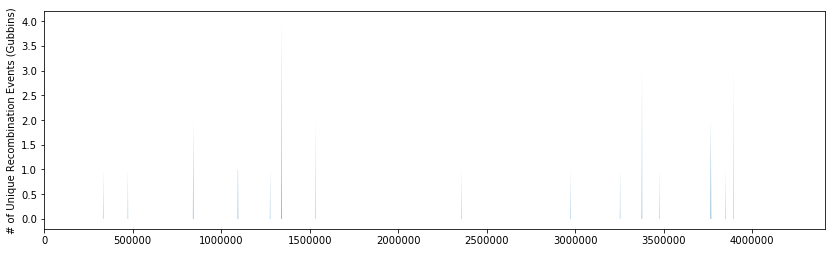

In [51]:
fig, axs = plt.subplots(1, 1, figsize=(14, 4) ) #, sharex=True)

pos_Coords_1 = np.arange(0, 4411000 + 1000, 1000)
y_1 = Gubbins_1kb_DF["Num_UnqEvents"]

axs.fill_between(pos_Coords_1, y_1, alpha=0.7)
axs.set_ylabel('# of Unique Recombination Events (Gubbins)', fontsize = 10)
plt.xlim(0,4413000)


(0, 4413000)

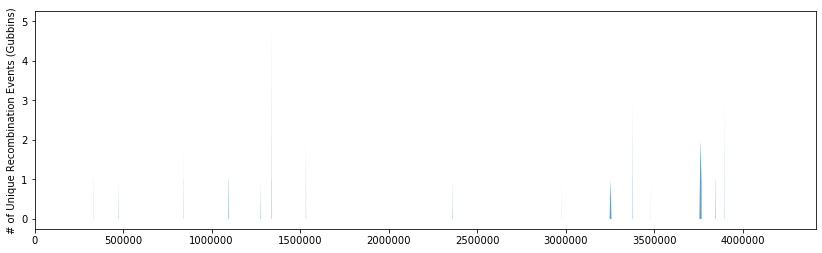

In [52]:
fig, axs = plt.subplots(1, 1, figsize=(14, 4) ) #, sharex=True)

axs.fill_between(Gubbins_GeneLevel_DF["CenterOfRegion"], Gubbins_GeneLevel_DF["Num_UnqEvents"], alpha=0.7)      

axs.set_ylabel('# of Unique Recombination Events (Gubbins)', fontsize = 10)
plt.xlim(0,4413000)


## Read in BRANCH-LEVEL stats for Gubbins recombination events

In [53]:
G_BranchStats_DF = pd.read_csv(G_BranchStats_WithLineage_CSV, sep = "\t")
G_BranchStats_DF.shape

(1873, 11)

## Eval Branch-stats from Gubbins

In [54]:
G_BranchStats_DF.sort_values("Num of Recombination Blocks", ascending=False).head(10)

,Node,Total SNPs,Num of SNPs inside recombinations,Num of SNPs outside recombinations,Num of Recombination Blocks,Bases in Recombinations,r/m,rho/theta,Genome Length,Bases in Clonal Frame,Lineage
16,SRR6807728,289,17,272,2,353,0.062500,0.007353,4411524,4411524,lineage4
954,internal_964,102,13,89,2,1460,0.146067,0.022472,4411448,4411180,lineage4
761,SRR10397246,76,5,71,1,121,0.070423,0.014085,4411504,4411504,lineage4
1318,internal_1167,122,5,117,1,506,0.042735,0.008547,4411532,4411532,lineage4
215,SRR6807674,15,6,9,1,737,0.666667,0.111111,4411530,4410962,lineage4
166,SRR10397175,19,7,12,1,779,0.583333,0.083333,4411531,4411531,lineage2
1314,internal_1181,76,7,69,1,566,0.101449,0.014493,4411532,4411025,lineage4
1133,internal_1140,86,7,79,1,18,0.088608,0.012658,4411516,4411516,lineage4
1022,internal_1039,150,6,144,1,609,0.041667,0.006944,4411528,4411528,lineage4
995,internal_995,67,6,61,1,112,0.098361,0.016393,4411508,4411415,lineage4


In [55]:
G_BranchStats_DF.tail()

,Node,Total SNPs,Num of SNPs inside recombinations,Num of SNPs outside recombinations,Num of Recombination Blocks,Bases in Recombinations,r/m,rho/theta,Genome Length,Bases in Clonal Frame,Lineage
1868,internal_1332,176,0,176,0,0,0.0,0.0,4411532,4411532,lineage2
1869,internal_1328,24,0,24,0,0,0.0,0.0,4411532,4411532,lineage2
1870,internal_1327,77,0,77,0,0,0.0,0.0,4411532,4411532,lineage2
1871,internal_1325,454,0,454,0,0,0.0,0.0,4411532,4411532,NaN
1872,internal_ROOT,0,0,0,0,0,0.0,0.0,4411532,4411532,NaN


In [56]:
G_BranchStats_DF["Num of Recombination Blocks"].max()

2

(array([1848.,   23.,    2.,    0.,    0.,    0.,    0.,    0.,    0.]),
 array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 <a list of 9 Patch objects>)

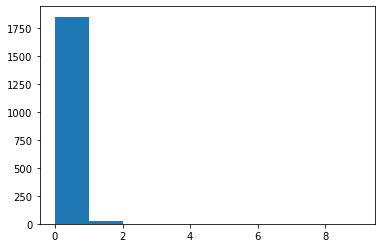

In [57]:
plt.hist(G_BranchStats_DF["Num of Recombination Blocks"], bins= np.arange(0,10,1))

In [58]:
G_BranchStats_DF[G_BranchStats_DF["Num of Recombination Blocks"] > 1]

,Node,Total SNPs,Num of SNPs inside recombinations,Num of SNPs outside recombinations,Num of Recombination Blocks,Bases in Recombinations,r/m,rho/theta,Genome Length,Bases in Clonal Frame,Lineage
16,SRR6807728,289,17,272,2,353,0.062500,0.007353,4411524,4411524,lineage4
954,internal_964,102,13,89,2,1460,0.146067,0.022472,4411448,4411180,lineage4


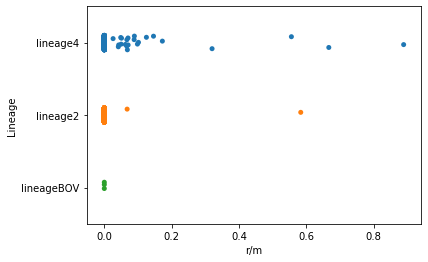

In [59]:
sns.stripplot(y = "Lineage", x = "r/m", data=G_BranchStats_DF)

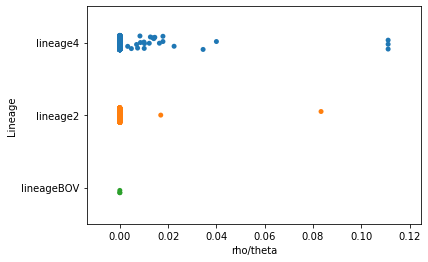

In [60]:
sns.stripplot(y = "Lineage", x = "rho/theta", data=G_BranchStats_DF)

## Define function for plotting phylogeny of putative recomb event

In [61]:
#def plotRecombOnPhylo(i_ParentNode_Name, i_ChildNode_Name, input_Tree):
def subset_Phylo_ForRecombViz(i_ParentNode_Name, i_ChildNode_Name, input_Tree):

    # Draws nodes as small red spheres of diameter equal to 10 pixels
    i_nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style
    i_nstyle["shape"] = "sphere"
    i_nstyle["size"] = 10
    i_nstyle["fgcolor"] = "darkred"

    i_SubTree_AtParentNode = input_Tree.search_nodes(name = i_ParentNode_Name)[0].copy()

    for n in i_SubTree_AtParentNode.traverse():
        if n.name == i_ChildNode_Name:
            n.set_style(i_nstyle)
    
    return i_SubTree_AtParentNode
    
    #i_SubTree_AtParentNode.render("%%inline", w = 400)
    #i_SubTree_AtParentNode.show()
    print(i_SubTree_AtParentNode)

## Parse Phylogeny (NEWICK) output by Gubbins

In [62]:
Mtb_48CI_FastTree_T = Tree(Gubbins_NodeLabelledTree_PATH, format = 1)
#Mtb_48CI_FastTree_RootPoint = Mtb_48CI_FastTree_T.get_leaves_by_name("RW-TB008")[0]
#Mtb_48CI_FastTree_RootPoint = Mtb_48CI_FastTree_T.get_leaves_by_name("internal_91")[0]
#Mtb_48CI_FastTree_T.set_outgroup(Mtb_48CI_FastTree_RootPoint)

In [63]:
count = 0

for n in Mtb_48CI_FastTree_T.get_leaves():
    n.add_feature("Mtb_lineage", ID_To_Lineage_Dict.get(n.name, "Unknown Lineage") ) 
    #print("node:", n.name, " Lineage:", n.Mtb_lineage)
    count +=1

print(count)

Mtb_48CI_FastTree_T.sort_descendants(attr='Mtb_lineage')

937


In [64]:
def Mtb_IDandLineage_Layout(node):
    F = ETE.TextFace(node.name, fsize=2)
    if node.is_leaf():
        NameAnd_Lineage_Text =  f"  {node.name} {node.Mtb_lineage}"
        F_NameAndLineage = ETE.TextFace(NameAnd_Lineage_Text, fsize=3)
        
        ETE.add_face_to_node(F_NameAndLineage, node, column=0, position="branch-right")

        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style
        nstyle["fgcolor"] = "black"
        nstyle["size"] = 1
        node.set_style(nstyle)
        node.margin_left = 10        
    else: 
        #print("")
        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style
        nstyle["fgcolor"] = "black"
        nstyle["size"] = 0
        node.set_style(nstyle)
        
ts_1 = ETE.TreeStyle()
ts_1.mode = "c" # draw tree in circular mode
ts_1.show_leaf_name = False
ts_1.show_branch_length = False
ts_1.show_branch_support = False
ts_1.show_scale = False #True
ts_1.branch_vertical_margin = 2
ts_1.layout_fn = Mtb_IDandLineage_Layout


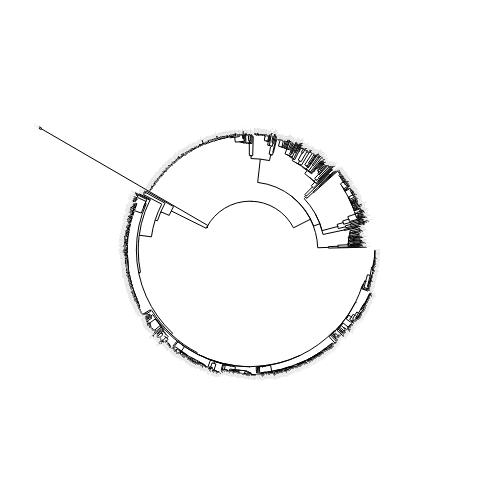

In [65]:
#Mtb_48CI_FastTree_T.render("%%inline", w = 200)
Mtb_48CI_FastTree_T.render("%%inline", w = 500, tree_style = ts_1)

In [66]:
Gubbins_Recomb_Events_DF.head(2).tail(1)

,seqname,source,feature,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,Lineage,CenterOfRegion,Rv_GeneID_Center,Symbol_Center,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,Num_Overlap_Homologous_Regions
1,NC_000962.3,GUBBINS,CDS,473800,473971,0.0,.,internal_1262,SRR6807674,70.598206,6,['SRR6807674'],lineage4,473885.0,Rv0393,Rv0393,Rv0393,Rv0393,False,False,True,False,Event_002,1


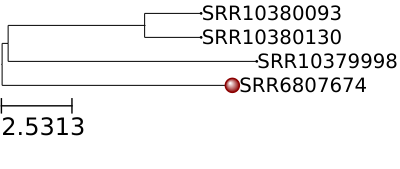

In [67]:
test1_SubTree_AtParentNode = subset_Phylo_ForRecombViz("internal_1262", "SRR6807674", Mtb_48CI_FastTree_T)      
test1_SubTree_AtParentNode.render("%%inline", w = 400)


# Putative Recombination Events Exploration:

In [68]:
Gubbins_Recomb_Events_DF.shape

(27, 24)

In [69]:
Gubbins_Recomb_Events_DF.query("NoOverlap_Wi_PEPPE_Esx_13E12_Genes == True ").shape

(7, 24)

In [70]:
#Gubbins_Recomb_Events_DF.query("NoOverlap_Wi_PEPPE_Esx_13E12_Genes == True ")

In [71]:
Mtb_HM_PAF_DF_NoOverlapRegions.head(1)

,Query_Start,Query_End,Strand,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,Prop_Match,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,Query_Contains_Esx,Query_Contains_PEPPE,Query_Contains_REP13E12,Query_NoOverlap_Wi_PEPPE_Esx_13E12_Genes
0,103705,105090,-,3883535,3884921,1346,1390,0.968345,3884228.0,104397.5,3779830.5,1385,1386,"Rv0094c,Rv0095c","Rv3466,Rv3467",False,False,True,False


# A) Evaluate and identify the genes of interest

### EventIDs of interest:
1) Event_001 (vapC25,vapB25) <br>
2) Event_003 (vapB31,vapC31) <br>
3) Event_004 <br>
4) Event_006 ?<br>
5) Event_009 (PPE18) <br>
6) Event_014 (PPE19) <br>
7) Event_019 (PPE46) <br>
8) Event_026/Event_027 <br>



In [72]:
#Gubbins_Recomb_Events_DF.head()

In [73]:
Gubbins_Recomb_Events_DF.columns

Index(['seqname', 'source', 'feature', 'start_1based', 'end_1based', 'score', 'strand', 'Parent_Node', 'Child_Node', 'neg_log_likelihood', 'snp_count', 'taxa_List', 'Lineage', 'CenterOfRegion', 'Rv_GeneID_Center', 'Symbol_Center', 'Overlap_Genes', 'Overlap_Gene_RvIDs', 'Contains_Esx', 'Contains_PEPPE', 'Contains_REP13E12', 'NoOverlap_Wi_PEPPE_Esx_13E12_Genes', 'EventID', 'Num_Overlap_Homologous_Regions'], dtype='object')

In [86]:
Gubbins_Recomb_Events_DF["LenOfTaxaList"] = Gubbins_Recomb_Events_DF["taxa_List"].apply(len)

In [87]:
TargetColn = ["start_1based", "end_1based", "Parent_Node", "Child_Node", "snp_count", 'taxa_List', "Lineage", "Overlap_Genes", "EventID", "Num_Overlap_Homologous_Regions", "LenOfTaxaList"]

In [88]:
Gubbins_Recomb_Events_DF[TargetColn]

,start_1based,end_1based,Parent_Node,Child_Node,snp_count,taxa_List,Lineage,Overlap_Genes,EventID,Num_Overlap_Homologous_Regions,LenOfTaxaList
0,333120,333212,internal_985,internal_986,8,"['SRR10379945', 'SRR7516364', 'SRR10380193', '...",lineage4,"vapC25,vapB25",Event_001,1,498
1,473800,473971,internal_1262,SRR6807674,6,['SRR6807674'],lineage4,Rv0393,Event_002,1,14
2,841087,841448,internal_1061,internal_1062,14,"['SRR10380227', 'SRR10379958']",lineage4,"vapB31,vapC31",Event_003,1,30
3,842026,842065,internal_941,SRR6807728,9,['SRR6807728'],lineage4,Rv0750,Event_004,1,14
4,842051,842111,internal_1177,internal_1181,7,"['SRR6807675', 'SRR10379983', 'SRR6807700', 'S...",lineage4,Rv0750,Event_005,1,2138
5,1094538,1095317,internal_1505,SRR10397175,7,['SRR10397175'],lineage2,"Rv0979c,rpmF,PE_PGRS18",Event_006,3,15
6,1276321,1276588,internal_943,internal_946,5,"['SRR10380134', 'SRR10380230', 'SRR10379994', ...",lineage4,Rv1148c,Event_007,1,311
7,1339399,1339905,internal_1166,internal_1167,5,"['SRR6807683', 'SRR10380192', 'SRR7516429', 'S...",lineage4,PPE18,Event_008,2,2340
8,1339894,1340208,internal_941,SRR6807728,8,['SRR6807728'],lineage4,PPE18,Event_009,2,14
9,1340052,1341254,internal_953,SRR10380108,5,['SRR10380108'],lineage4,"PPE18,esxK,esxL",Event_010,6,15


In [ ]:
# DROP OUT 'Event_015' because it is happening in a gene with NO identified homologous sequence

In [225]:
Mtb_HM_PAF_DF_NoOverlapRegions[ Mtb_HM_PAF_DF_NoOverlapRegions["QueryOverlap_Genes"].str.contains("Rv0750") ]

,Query_Start,Query_End,Strand,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,Prop_Match,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,Query_Contains_Esx,Query_Contains_PEPPE,Query_Contains_REP13E12,Query_NoOverlap_Wi_PEPPE_Esx_13E12_Genes
11,842019,842331,+,832044,832356,301,312,0.964744,832200.0,842175.0,9975.0,312,312,Rv0750,Rv0740,False,False,False,True


## Explore "Event_001"

NOTEs: Looks legit, do it

All Nodes ['SRR10379893', 'SRR10379975', 'SRR10379952', 'SRR10379911', 'SRR6807680', 'SRR10379920', 'SRR10380180', 'SRR6807761', 'SRR10380229', 'SRR10380027', 'SRR7516342', 'SRR7516365', 'SRR10380175', 'SRR10380084', 'SRR10380189', 'SRR10380146', 'SRR10397170', 'SRR10397124', 'SRR7516450', 'SRR7516306', 'SRR10379925', 'SRR6356930', 'SRR6356936', 'SRR10397191', 'SRR7516329', 'SRR10379907', 'SRR7516415', 'SRR10380067', 'SRR10397196', 'SRR6356923', 'SRR10380193', 'SRR10379902', 'SRR10379945', 'SRR7516364', 'SRR10397263', 'SRR10397220', 'SRR10397258', 'SRR10379915', 'SRR10380016', 'SRR10380026', 'SRR10379961', 'SRR10380141', 'SRR10380112', 'SRR10380179', 'SRR7516350', 'SRR7516351', 'SRR7516434']

Affected leaf names: ['SRR10379893', 'SRR10379975', 'SRR10379952', 'SRR10379911', 'SRR6807680', 'SRR10379920', 'SRR10380180', 'SRR6807761', 'SRR10380229', 'SRR10380027', 'SRR7516342', 'SRR7516365', 'SRR10380175', 'SRR10380084', 'SRR10380189', 'SRR10380146', 'SRR10397170', 'SRR10397124', 'SRR751645

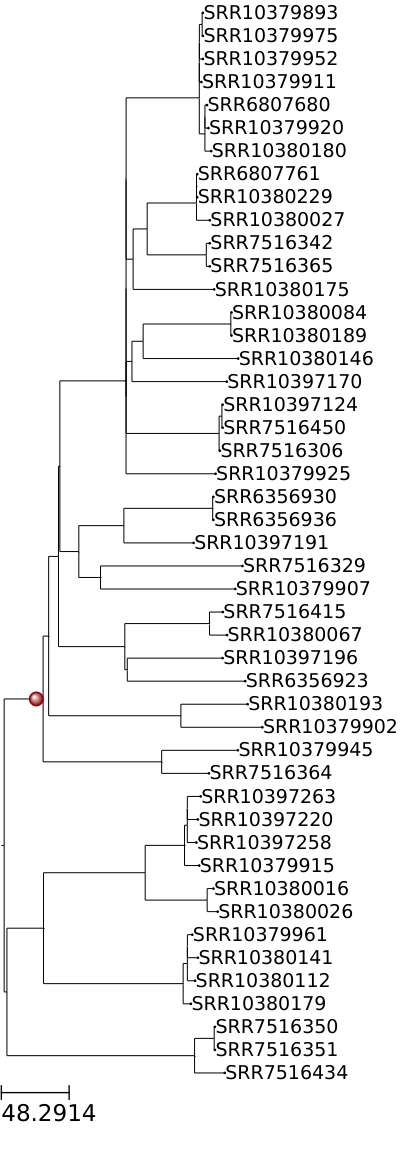

In [226]:
GRE_DF = Gubbins_Recomb_Events_DF.query("EventID == 'Event_001' ")


i_ParentNode_Name = GRE_DF["Parent_Node"].values[0]
i_ChildNode_Name = GRE_DF["Child_Node"].values[0]


test1_SubTree_AtParentNode = subset_Phylo_ForRecombViz(i_ParentNode_Name,
                                                       i_ChildNode_Name,
                                                       Mtb_48CI_FastTree_T)  


for n in test1_SubTree_AtParentNode.traverse():
    if n.name == i_ChildNode_Name: Affected_LeafNames = n.get_leaf_names()
    if n.name == i_ParentNode_Name: All_Leaf_Names = n.get_leaf_names()

    
# https://stackoverflow.com/questions/3428536/python-list-subtraction-operation
NotAffected_LeafNames = [item for item in All_Leaf_Names if item not in Affected_LeafNames]

    
print("All Nodes", All_Leaf_Names)
print()
print("Affected leaf names:", Affected_LeafNames)
print()
print("Not affected leaf names:", NotAffected_LeafNames)


test1_SubTree_AtParentNode.render("%%inline", w = 400)


In [227]:
GRE_DF

,seqname,source,feature,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,Lineage,CenterOfRegion,Rv_GeneID_Center,Symbol_Center,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,Num_Overlap_Homologous_Regions
0,NC_000962.3,GUBBINS,CDS,333120,333212,0.0,.,internal_985,internal_986,158.013591,8,"['SRR10379945', 'SRR7516364', 'SRR10380193', '...",lineage4,333165.5,NaN,NaN,"vapC25,vapB25","Rv0277c,Rv0277A",False,False,False,True,Event_001,1


## Explore "Event_003"

NOTEs: 

All Nodes ['SRR10380218', 'SRR10380217', 'SRR10397107', 'SRR6356960', 'SRR10380227', 'SRR10379958']

Affected leaf names: ['SRR10380227', 'SRR10379958']

Not affected leaf names: ['SRR10380218', 'SRR10380217', 'SRR10397107', 'SRR6356960']


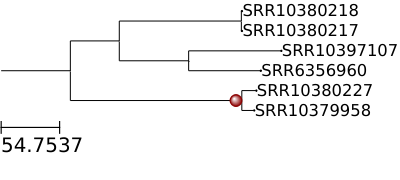

In [243]:
GRE_DF = Gubbins_Recomb_Events_DF.query("EventID == 'Event_003' ")


i_ParentNode_Name = GRE_DF["Parent_Node"].values[0]
i_ChildNode_Name = GRE_DF["Child_Node"].values[0]


test1_SubTree_AtParentNode = subset_Phylo_ForRecombViz(i_ParentNode_Name,
                                                       i_ChildNode_Name,
                                                       Mtb_48CI_FastTree_T)  


for n in test1_SubTree_AtParentNode.traverse():
    if n.name == i_ChildNode_Name: Affected_LeafNames = n.get_leaf_names()
    if n.name == i_ParentNode_Name: All_Leaf_Names = n.get_leaf_names()

    
# https://stackoverflow.com/questions/3428536/python-list-subtraction-operation
NotAffected_LeafNames = [item for item in All_Leaf_Names if item not in Affected_LeafNames]

    
print("All Nodes", All_Leaf_Names)
print()
print("Affected leaf names:", Affected_LeafNames)
print()
print("Not affected leaf names:", NotAffected_LeafNames)


test1_SubTree_AtParentNode.render("%%inline", w = 400)


In [229]:
GRE_DF

,seqname,source,feature,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,Lineage,CenterOfRegion,Rv_GeneID_Center,Symbol_Center,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,Num_Overlap_Homologous_Regions
2,NC_000962.3,GUBBINS,CDS,841087,841448,0.0,.,internal_1061,internal_1062,1023.196321,14,"['SRR10380227', 'SRR10379958']",lineage4,841267.0,Rv0749,vapC31,"vapB31,vapC31","Rv0748,Rv0749",False,False,False,True,Event_003,1


## Explore "Event_004"

NOTEs: 

All Nodes ['SRR10379935', 'SRR10380049', 'SRR10380225', 'SRR10397250', 'SRR7516407', 'SRR10379924', 'SRR10380108', 'SRR10380198', 'SRR10380200', 'SRR10380195', 'SRR6807722', 'SRR6807671', 'SRR10379888', 'SRR10379937', 'SRR10380210', 'SRR10380212', 'SRR10379962', 'SRR6807738', 'SRR10380230', 'SRR10379994', 'SRR10380134', 'SRR10380054', 'SRR7516353', 'SRR7516357', 'SRR10397269', 'SRR6807728']

Affected leaf names: ['SRR6807728']

Not affected leaf names: ['SRR10379935', 'SRR10380049', 'SRR10380225', 'SRR10397250', 'SRR7516407', 'SRR10379924', 'SRR10380108', 'SRR10380198', 'SRR10380200', 'SRR10380195', 'SRR6807722', 'SRR6807671', 'SRR10379888', 'SRR10379937', 'SRR10380210', 'SRR10380212', 'SRR10379962', 'SRR6807738', 'SRR10380230', 'SRR10379994', 'SRR10380134', 'SRR10380054', 'SRR7516353', 'SRR7516357', 'SRR10397269']


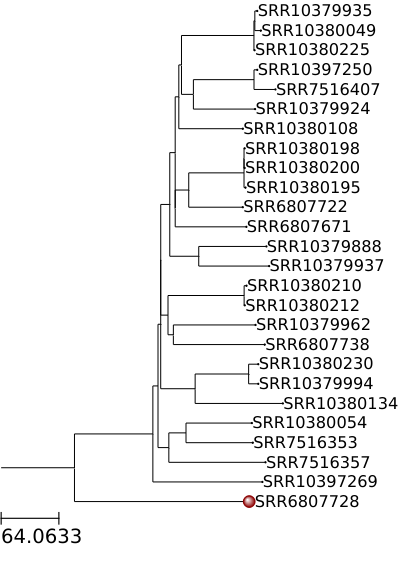

In [230]:
GRE_DF = Gubbins_Recomb_Events_DF.query("EventID == 'Event_004' ")


i_ParentNode_Name = GRE_DF["Parent_Node"].values[0]
i_ChildNode_Name = GRE_DF["Child_Node"].values[0]


test1_SubTree_AtParentNode = subset_Phylo_ForRecombViz(i_ParentNode_Name,
                                                       i_ChildNode_Name,
                                                       Mtb_48CI_FastTree_T)  


for n in test1_SubTree_AtParentNode.traverse():
    if n.name == i_ChildNode_Name: Affected_LeafNames = n.get_leaf_names()
    if n.name == i_ParentNode_Name: All_Leaf_Names = n.get_leaf_names()

    
# https://stackoverflow.com/questions/3428536/python-list-subtraction-operation
NotAffected_LeafNames = [item for item in All_Leaf_Names if item not in Affected_LeafNames]

    
print("All Nodes", All_Leaf_Names)
print()
print("Affected leaf names:", Affected_LeafNames)
print()
print("Not affected leaf names:", NotAffected_LeafNames)


test1_SubTree_AtParentNode.render("%%inline", w = 400)


In [231]:
GRE_DF

,seqname,source,feature,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,Lineage,CenterOfRegion,Rv_GeneID_Center,Symbol_Center,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,Num_Overlap_Homologous_Regions
3,NC_000962.3,GUBBINS,CDS,842026,842065,0.0,.,internal_941,SRR6807728,1309.669305,9,['SRR6807728'],lineage4,842045.0,Rv0750,Rv0750,Rv0750,Rv0750,False,False,False,True,Event_004,1


## Explore "Event_006"

NOTEs:

All Nodes ['SRR7516362', 'SRR10397127', 'SRR10397224', 'SRR7516381', 'SRR10397113', 'SRR7516352', 'SRR7516355', 'SRR7516361', 'SRR10397096', 'SRR10397175']

Affected leaf names: ['SRR10397175']

Not affected leaf names: ['SRR7516362', 'SRR10397127', 'SRR10397224', 'SRR7516381', 'SRR10397113', 'SRR7516352', 'SRR7516355', 'SRR7516361', 'SRR10397096']


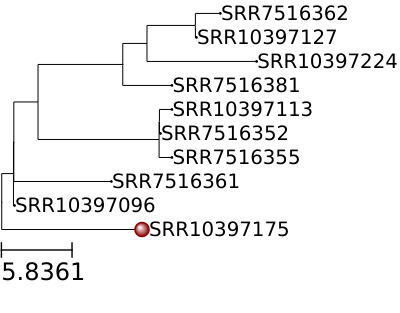

In [232]:
GRE_DF = Gubbins_Recomb_Events_DF.query("EventID == 'Event_006' ")


i_ParentNode_Name = GRE_DF["Parent_Node"].values[0]
i_ChildNode_Name = GRE_DF["Child_Node"].values[0]


test1_SubTree_AtParentNode = subset_Phylo_ForRecombViz(i_ParentNode_Name,
                                                       i_ChildNode_Name,
                                                       Mtb_48CI_FastTree_T)  


for n in test1_SubTree_AtParentNode.traverse():
    if n.name == i_ChildNode_Name: Affected_LeafNames = n.get_leaf_names()
    if n.name == i_ParentNode_Name: All_Leaf_Names = n.get_leaf_names()

    
# https://stackoverflow.com/questions/3428536/python-list-subtraction-operation
NotAffected_LeafNames = [item for item in All_Leaf_Names if item not in Affected_LeafNames]

    
print("All Nodes", All_Leaf_Names)
print()
print("Affected leaf names:", Affected_LeafNames)
print()
print("Not affected leaf names:", NotAffected_LeafNames)


test1_SubTree_AtParentNode.render("%%inline", w = 400)


In [233]:
GRE_DF

,seqname,source,feature,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,Lineage,CenterOfRegion,Rv_GeneID_Center,Symbol_Center,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,Num_Overlap_Homologous_Regions
5,NC_000962.3,GUBBINS,CDS,1094538,1095317,0.0,.,internal_1505,SRR10397175,92.819244,7,['SRR10397175'],lineage2,1094927.0,Rv0979A,rpmF,"Rv0979c,rpmF,PE_PGRS18","Rv0979c,Rv0979A,Rv0980c",False,True,False,False,Event_006,3


## Explore "Event_009"

NOTEs: 

All Nodes ['SRR10379935', 'SRR10380049', 'SRR10380225', 'SRR10397250', 'SRR7516407', 'SRR10379924', 'SRR10380108', 'SRR10380198', 'SRR10380200', 'SRR10380195', 'SRR6807722', 'SRR6807671', 'SRR10379888', 'SRR10379937', 'SRR10380210', 'SRR10380212', 'SRR10379962', 'SRR6807738', 'SRR10380230', 'SRR10379994', 'SRR10380134', 'SRR10380054', 'SRR7516353', 'SRR7516357', 'SRR10397269', 'SRR6807728']

Affected leaf names: ['SRR6807728']

Not affected leaf names: ['SRR10379935', 'SRR10380049', 'SRR10380225', 'SRR10397250', 'SRR7516407', 'SRR10379924', 'SRR10380108', 'SRR10380198', 'SRR10380200', 'SRR10380195', 'SRR6807722', 'SRR6807671', 'SRR10379888', 'SRR10379937', 'SRR10380210', 'SRR10380212', 'SRR10379962', 'SRR6807738', 'SRR10380230', 'SRR10379994', 'SRR10380134', 'SRR10380054', 'SRR7516353', 'SRR7516357', 'SRR10397269']


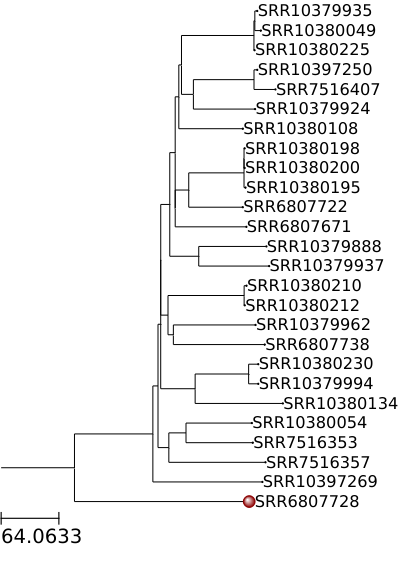

In [234]:
GRE_DF = Gubbins_Recomb_Events_DF.query("EventID == 'Event_009' ")


i_ParentNode_Name = GRE_DF["Parent_Node"].values[0]
i_ChildNode_Name = GRE_DF["Child_Node"].values[0]


test1_SubTree_AtParentNode = subset_Phylo_ForRecombViz(i_ParentNode_Name,
                                                       i_ChildNode_Name,
                                                       Mtb_48CI_FastTree_T)  


for n in test1_SubTree_AtParentNode.traverse():
    if n.name == i_ChildNode_Name: Affected_LeafNames = n.get_leaf_names()
    if n.name == i_ParentNode_Name: All_Leaf_Names = n.get_leaf_names()

    
# https://stackoverflow.com/questions/3428536/python-list-subtraction-operation
NotAffected_LeafNames = [item for item in All_Leaf_Names if item not in Affected_LeafNames]

    
print("All Nodes", All_Leaf_Names)
print()
print("Affected leaf names:", Affected_LeafNames)
print()
print("Not affected leaf names:", NotAffected_LeafNames)


test1_SubTree_AtParentNode.render("%%inline", w = 400)


In [235]:
GRE_DF

,seqname,source,feature,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,Lineage,CenterOfRegion,Rv_GeneID_Center,Symbol_Center,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,Num_Overlap_Homologous_Regions
8,NC_000962.3,GUBBINS,CDS,1339894,1340208,0.0,.,internal_941,SRR6807728,1282.018277,8,['SRR6807728'],lineage4,1340050.5,NaN,NaN,PPE18,Rv1196,False,True,False,False,Event_009,2


## Explore "Event_014"

NOTEs: 

All Nodes ['SRR7516312', 'SRR7516323', 'SRR10430368', 'SRR10430344', 'SRR10430394', 'SRR10430365', 'SRR10430318', 'SRR6807707', 'SRR10430383', 'SRR10397166', 'SRR10430381', 'SRR10430385', 'SRR10430348', 'SRR10430317', 'SRR10430342', 'SRR10430346', 'SRR10430356', 'SRR10430369', 'SRR10430382', 'SRR10430367', 'SRR7516413', 'SRR10430357', 'SRR10430395', 'SRR10430363', 'SRR10430361', 'SRR10430380', 'SRR10430364', 'SRR10430397', 'SRR10430343', 'SRR10430388', 'SRR10430377', 'SRR10430349', 'SRR10430362', 'SRR10430352', 'SRR10430353', 'SRR10430401', 'SRR10380029', 'SRR10430393', 'SRR10430347', 'SRR6356945', 'SRR6356928', 'SRR6356939', 'SRR6356943', 'SRR6356969', 'SRR10397099', 'SRR6356953', 'SRR6356957', 'SRR10397120', 'SRR10430379', 'SRR10430324', 'SRR10430358', 'SRR10430322', 'SRR10379984', 'SRR10379943', 'SRR6807760', 'SRR10379977', 'SRR10379909', 'SRR10379969', 'SRR6807763', 'SRR10379964', 'SRR10379894', 'SRR10380074', 'SRR10379973', 'SRR10380092', 'SRR6807751', 'SRR10380196', 'SRR10380170'

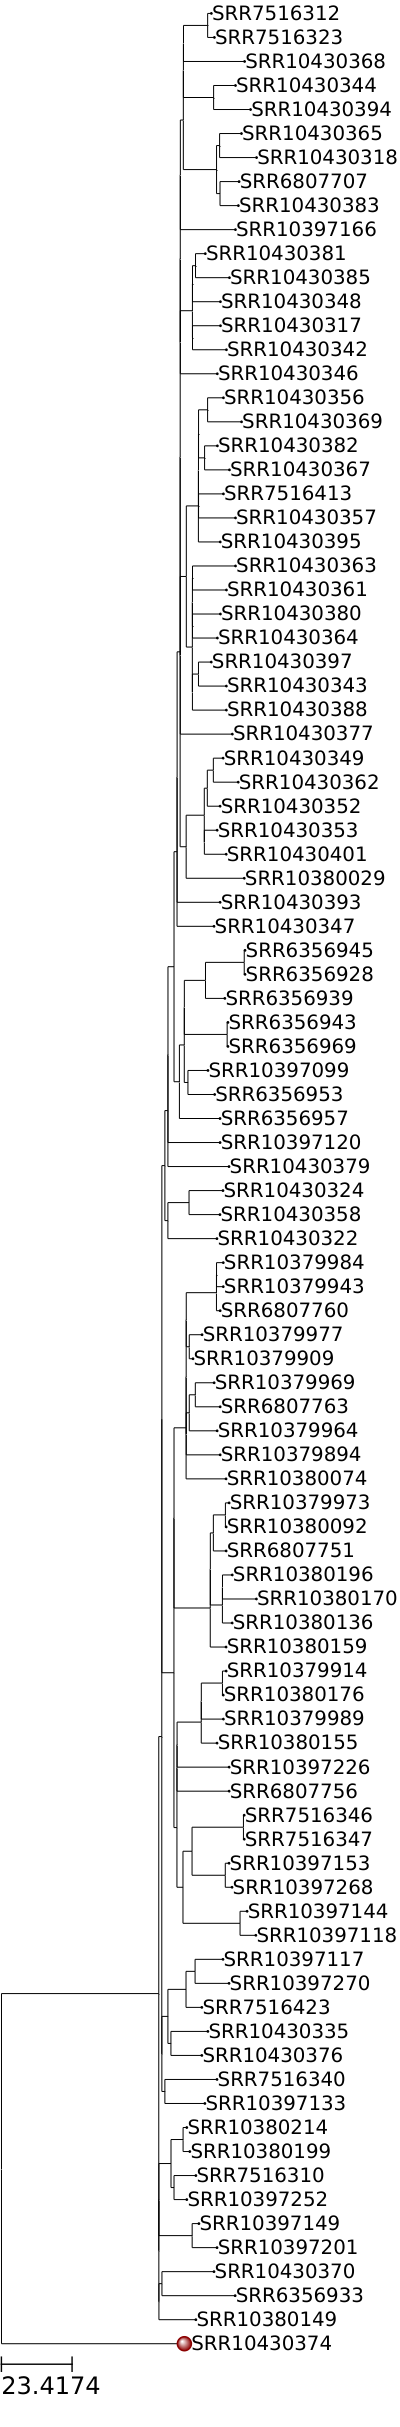

In [236]:
GRE_DF = Gubbins_Recomb_Events_DF.query("EventID == 'Event_014' ")


i_ParentNode_Name = GRE_DF["Parent_Node"].values[0]
i_ChildNode_Name = GRE_DF["Child_Node"].values[0]


test1_SubTree_AtParentNode = subset_Phylo_ForRecombViz(i_ParentNode_Name,
                                                       i_ChildNode_Name,
                                                       Mtb_48CI_FastTree_T)  


for n in test1_SubTree_AtParentNode.traverse():
    if n.name == i_ChildNode_Name: Affected_LeafNames = n.get_leaf_names()
    if n.name == i_ParentNode_Name: All_Leaf_Names = n.get_leaf_names()

    
# https://stackoverflow.com/questions/3428536/python-list-subtraction-operation
NotAffected_LeafNames = [item for item in All_Leaf_Names if item not in Affected_LeafNames]

    
print("All Nodes", All_Leaf_Names)
print()
print("Affected leaf names:", Affected_LeafNames)
print()
print("Not affected leaf names:", NotAffected_LeafNames)


test1_SubTree_AtParentNode.render("%%inline", w = 400)


In [237]:
GRE_DF

,seqname,source,feature,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,Lineage,CenterOfRegion,Rv_GeneID_Center,Symbol_Center,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,Num_Overlap_Homologous_Regions
13,NC_000962.3,GUBBINS,CDS,1533268,1533275,0.0,.,internal_1544,SRR10430374,320.119481,4,['SRR10430374'],lineage2,1533271.0,Rv1361c,PPE19,PPE19,Rv1361c,False,True,False,False,Event_014,2


## Explore "Event_019"

NOTEs: 

All Nodes ['SRR6356932', 'SRR6356979', 'SRR6356981', 'SRR6356924', 'SRR6356962', 'SRR6356927', 'SRR10397092', 'SRR6807754', 'SRR10379910', 'SRR10397266', 'SRR10397217', 'SRR10380106', 'SRR10380135', 'SRR10397183', 'SRR10397186', 'SRR10397193', 'SRR7516303', 'SRR10380216', 'SRR7516368', 'SRR7516369', 'SRR10430321', 'SRR10380102', 'SRR10380197', 'SRR10430354', 'SRR7516397', 'SRR10379959', 'SRR6356973', 'SRR10380236', 'SRR10380237', 'SRR10379881', 'SRR10379880', 'SRR10397102', 'SRR7516410', 'SRR10397119', 'SRR7516356', 'SRR7516390', 'SRR10397176', 'SRR10430338', 'SRR10430351', 'SRR10430331', 'SRR10380233', 'SRR10380232', 'SRR7516421', 'SRR10379891', 'SRR10397177', 'SRR7516460', 'SRR7516363', 'SRR7516379', 'SRR6356989', 'SRR10380069', 'SRR10380127', 'SRR10380128', 'SRR6807734', 'SRR10397163', 'SRR10380173', 'SRR10430320', 'SRR6356986', 'SRR6356975', 'SRR7516438', 'SRR10397195', 'SRR6357002', 'SRR10380119', 'SRR10397178', 'SRR10397108', 'SRR10380205', 'SRR6356978', 'SRR10380207', 'SRR635694

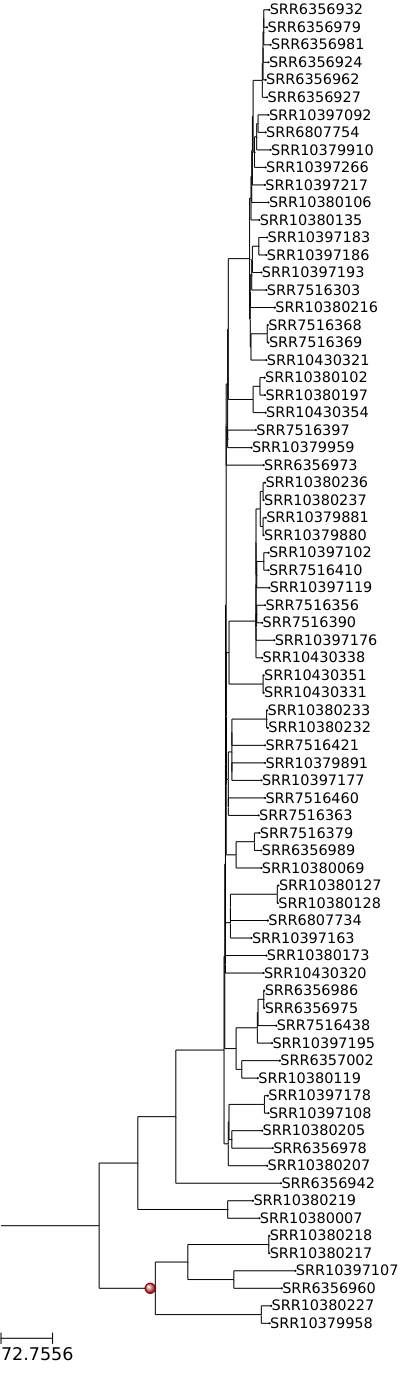

In [238]:
GRE_DF = Gubbins_Recomb_Events_DF.query("EventID == 'Event_019' ")


i_ParentNode_Name = GRE_DF["Parent_Node"].values[0]
i_ChildNode_Name = GRE_DF["Child_Node"].values[0]


test1_SubTree_AtParentNode = subset_Phylo_ForRecombViz(i_ParentNode_Name,
                                                       i_ChildNode_Name,
                                                       Mtb_48CI_FastTree_T)  


for n in test1_SubTree_AtParentNode.traverse():
    if n.name == i_ChildNode_Name: Affected_LeafNames = n.get_leaf_names()
    if n.name == i_ParentNode_Name: All_Leaf_Names = n.get_leaf_names()

    
# https://stackoverflow.com/questions/3428536/python-list-subtraction-operation
NotAffected_LeafNames = [item for item in All_Leaf_Names if item not in Affected_LeafNames]

    
print("All Nodes", All_Leaf_Names)
print()
print("Affected leaf names:", Affected_LeafNames)
print()
print("Not affected leaf names:", NotAffected_LeafNames)


test1_SubTree_AtParentNode.render("%%inline", w = 400)


In [239]:
GRE_DF

,seqname,source,feature,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,Lineage,CenterOfRegion,Rv_GeneID_Center,Symbol_Center,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,Num_Overlap_Homologous_Regions
18,NC_000962.3,GUBBINS,CDS,3377271,3377320,0.0,.,internal_1060,internal_1061,613.252749,8,"['SRR10380227', 'SRR10379958', 'SRR10380218', ...",lineage4,3377295.0,Rv3018c,PPE46,PPE46,Rv3018c,False,True,False,False,Event_019,1


In [240]:
#Event_026/Event_027

## Explore "Event_026/Event_027"

NOTEs: 

All Nodes ['SRR10380054', 'SRR7516353', 'SRR7516357']

Affected leaf names: ['SRR10380054', 'SRR7516353']

Not affected leaf names: ['SRR7516357']


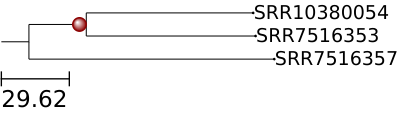

In [241]:
GRE_DF = Gubbins_Recomb_Events_DF.query("EventID == 'Event_026' ")


i_ParentNode_Name = GRE_DF["Parent_Node"].values[0]
i_ChildNode_Name = GRE_DF["Child_Node"].values[0]


test1_SubTree_AtParentNode = subset_Phylo_ForRecombViz(i_ParentNode_Name,
                                                       i_ChildNode_Name,
                                                       Mtb_48CI_FastTree_T)  


for n in test1_SubTree_AtParentNode.traverse():
    if n.name == i_ChildNode_Name: Affected_LeafNames = n.get_leaf_names()
    if n.name == i_ParentNode_Name: All_Leaf_Names = n.get_leaf_names()

    
# https://stackoverflow.com/questions/3428536/python-list-subtraction-operation
NotAffected_LeafNames = [item for item in All_Leaf_Names if item not in Affected_LeafNames]

    
print("All Nodes", All_Leaf_Names)
print()
print("Affected leaf names:", Affected_LeafNames)
print()
print("Not affected leaf names:", NotAffected_LeafNames)


test1_SubTree_AtParentNode.render("%%inline", w = 400)


In [242]:
GRE_DF

,seqname,source,feature,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,Lineage,CenterOfRegion,Rv_GeneID_Center,Symbol_Center,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,Num_Overlap_Homologous_Regions
25,NC_000962.3,GUBBINS,CDS,3894773,3894791,0.0,.,internal_944,internal_945,516.670442,5,"['SRR10380054', 'SRR7516353']",lineage4,3894781.5,NaN,NaN,PPE60,Rv3478,False,True,False,False,Event_026,2


In [141]:
Gubbins_Recomb_Events_DF[ Gubbins_Recomb_Events_DF["Overlap_Genes"].str.contains("PPE55") ]

,seqname,source,feature,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,Lineage,CenterOfRegion,Rv_GeneID_Center,Symbol_Center,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID
102,NC_000962.3,GUBBINS,CDS,3750177,3750421,0.0,.,internal_94,internal_95,1613.496173,11,"['mada_2-31', 'mada_1-41', 'R21839', 'R21363',...",lineage4,3750298.5,NaN,NaN,PPE55,Rv3347c,False,True,False,False,Event_103
103,NC_000962.3,GUBBINS,CDS,3752654,3752842,0.0,.,internal_101,R21363,277.280297,12,['R21363'],lineage4,3752747.5,NaN,NaN,PPE55,Rv3347c,False,True,False,False,Event_104


In [142]:
Gubbins_Recomb_Events_DF[ Gubbins_Recomb_Events_DF["Overlap_Genes"].str.contains("PPE57") ].shape

(11, 23)